# Experiment: ESS and MESS Uniform with Varying M

This notebook compares ESS (MESS with M=1) and MESS uniform for varying number of proposals M = [2, 5, 10, 50, 100, 500, 1000] on a GP regression problem with D=5 dimensions. We track the number of intervals (shrinking steps) as a function of M.

In [1]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")

import numpy as np
import matplotlib.pyplot as plt
from multiproposal.data.gp_regression import generate_gp_regression_data
from multiproposal.problems.gp_regression import GaussianProcessRegression
from multiproposal.algorithms.ess import ess_step
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import (
    estimate_effective_sample_size,
    compute_mean_squared_jumping_distance,
    compute_normalized_jumping_distance
)

Repo root: /Users/guillers/Documents/GitHub/multiproposal
Added to path: /Users/guillers/Documents/GitHub/multiproposal/src


## Experiment Setup

In [3]:
# Problem parameters
D = 5  # Dimension
num_data = 200
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 3000  # Number of MCMC iterations
burn_in = 500
seed = 42

# MESS M values to test
M_values = [1, 2, 5, 10, 25, 50, 75, 100, 500, 1000]
M_values = [1, 2, 5, 10, 20, 50, 100]

print(f"Experiment setup:")
print(f"  D = {D}")
print(f"  num_data = {num_data}")
print(f"  n_iters = {n_iters}")
print(f"  M values: {M_values}")


Experiment setup:
  D = 5
  num_data = 200
  n_iters = 3000
  M values: [1, 2, 5, 10, 20, 50, 100]


## Generate GP Regression Data

In [4]:
data = generate_gp_regression_data(
    num_data=num_data,
    num_dims=D,
    length_scale=length_scale,
    noise_variance=noise_variance,
    seed=seed,
)

X = data["X"]
y = data["y"]
x0 = data["f_init"]

print(f"Data shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  x0: {x0.shape}")

# Create the problem
problem = GaussianProcessRegression(
    X=X,
    y=y,
    length_scale=length_scale,
    noise_variance=noise_variance,
)
print(f"Initial log-likelihood: {problem.log_likelihood(x0):.4f}")


Data shapes:
  X: (5, 200)
  y: (200,)
  x0: (200,)
Initial log-likelihood: -2426.8620


## Run Experiments with Different M Values

For each M value, we run a full MCMC chain and collect statistics on the number of intervals (shrinking steps) performed by the algorithm.


In [5]:
# Store results
results = {
    'M_values': M_values,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

# Run experiments for each M value
for M in M_values:
    print(f"\nRunning MESS with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters, num_data))
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=False)
        chain[t] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results['mean_intervals'].append(mean_intervals)
    results['std_intervals'].append(std_intervals)
    results['median_intervals'].append(median_intervals)
    results['chains'][M] = chain
    results['intervals'][M] = intervals
    results['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment completed!")



Running MESS with M = 1...
  Mean intervals: 6.9676 ± 3.3753
  Median intervals: 7.0
  Time: 0.40 seconds

Running MESS with M = 2...
  Mean intervals: 4.0096 ± 1.9726
  Median intervals: 4.0
  Time: 0.32 seconds

Running MESS with M = 5...
  Mean intervals: 2.0312 ± 1.0609
  Median intervals: 2.0
  Time: 0.25 seconds

Running MESS with M = 10...
  Mean intervals: 1.2924 ± 0.7513
  Median intervals: 1.0
  Time: 0.24 seconds

Running MESS with M = 20...
  Mean intervals: 0.8748 ± 0.5837
  Median intervals: 1.0
  Time: 0.27 seconds

Running MESS with M = 50...
  Mean intervals: 0.5292 ± 0.5095
  Median intervals: 1.0
  Time: 0.42 seconds

Running MESS with M = 100...
  Mean intervals: 0.3232 ± 0.4686
  Median intervals: 0.0
  Time: 0.64 seconds

Experiment completed!


## Plot Results: Number of Intervals vs M

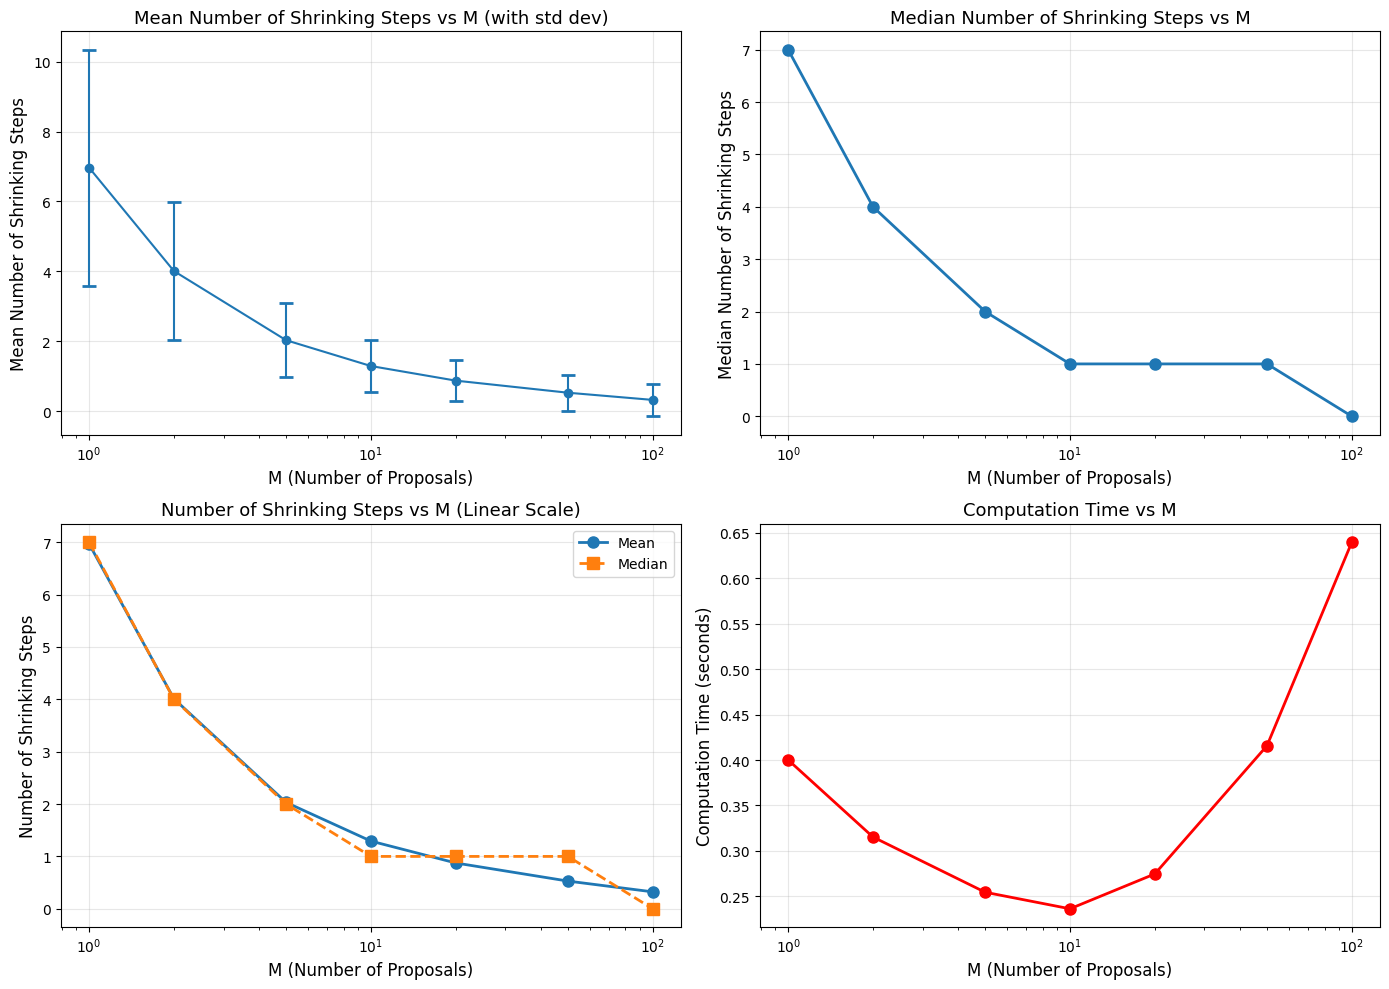


Summary Table:
M          Mean Int.       Std Dev         Median          Time (s)       
1          6.9676          3.3753          7.0             0.4001         
2          4.0096          1.9726          4.0             0.3153         
5          2.0312          1.0609          2.0             0.2546         
10         1.2924          0.7513          1.0             0.2363         
20         0.8748          0.5837          1.0             0.2747         
50         0.5292          0.5095          1.0             0.4157         
100        0.3232          0.4686          0.0             0.6397         


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean number of intervals with error bars
ax = axes[0, 0]
ax.errorbar(results['M_values'], results['mean_intervals'], 
            yerr=results['std_intervals'], fmt='o-', capsize=5, capthick=2)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Mean Number of Shrinking Steps', fontsize=12)
ax.set_title('Mean Number of Shrinking Steps vs M (with std dev)', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot 2: Median number of intervals
ax = axes[0, 1]
ax.plot(results['M_values'], results['median_intervals'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Median Number of Shrinking Steps', fontsize=12)
ax.set_title('Median Number of Shrinking Steps vs M', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot 3: Linear scale for comparison
ax = axes[1, 0]
ax.plot(results['M_values'], results['mean_intervals'], 'o-', linewidth=2, markersize=8, label='Mean')
ax.plot(results['M_values'], results['median_intervals'], 's--', linewidth=2, markersize=8, label='Median')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Number of Shrinking Steps', fontsize=12)
ax.set_title('Number of Shrinking Steps vs M (Linear Scale)', fontsize=13)
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Computation time
ax = axes[1, 1]
ax.plot(results['M_values'], results['times'], 'o-', linewidth=2, markersize=8, color='red')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Computation Time (seconds)', fontsize=12)
ax.set_title('Computation Time vs M', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary Table:")
print("="*80)
print(f"{'M':<10} {'Mean Int.':<15} {'Std Dev':<15} {'Median':<15} {'Time (s)':<15}")
print("="*80)
for i, M in enumerate(results['M_values']):
    print(f"{M:<10} {results['mean_intervals'][i]:<15.4f} {results['std_intervals'][i]:<15.4f} {results['median_intervals'][i]:<15.1f} {results['times'][i]:<15.4f}")
print("="*80)


## Trace Plots: Number of Intervals Over Iterations

Visualize how the number of intervals evolves during the MCMC chain for different M values.


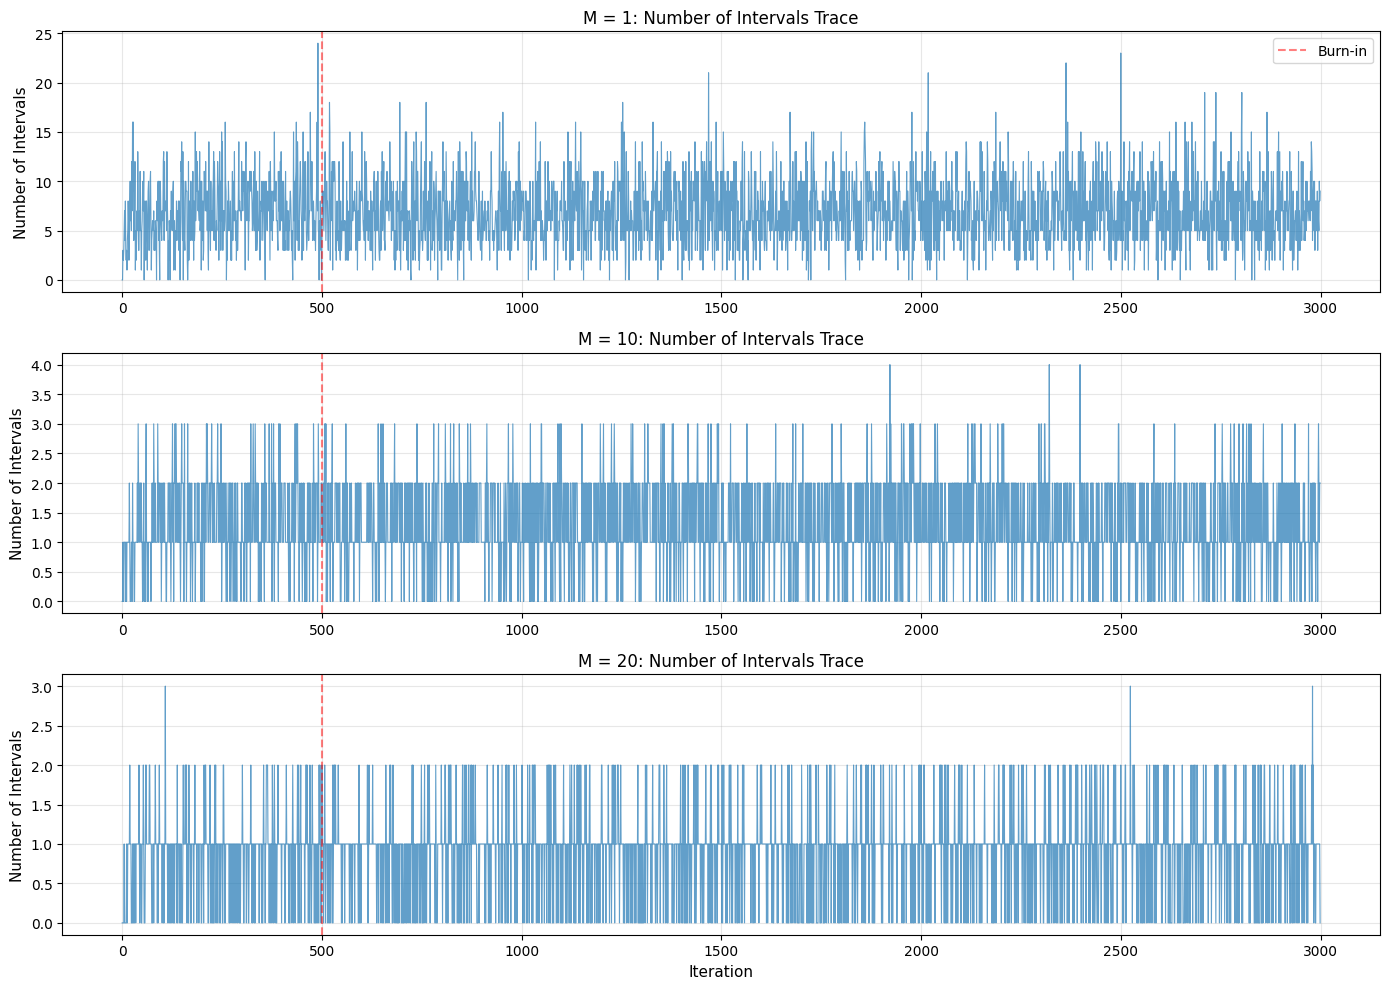

In [7]:
# Select a subset of M values for trace plot visualization
M_subset = [1, 10, 20]

fig, axes = plt.subplots(len(M_subset), 1, figsize=(14, 10))

for idx, M in enumerate(M_subset):
    ax = axes[idx]
    intervals_trace = results['intervals'][M]
    ax.plot(intervals_trace, alpha=0.7, linewidth=0.8)
    ax.axvline(burn_in, color='red', linestyle='--', alpha=0.5, label='Burn-in')
    ax.set_ylabel('Number of Intervals', fontsize=11)
    ax.set_title(f'M = {M}: Number of Intervals Trace', fontsize=12)
    ax.grid(True, alpha=0.3)
    if idx == len(M_subset) - 1:
        ax.set_xlabel('Iteration', fontsize=11)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


## Box Plots: Distribution of Intervals for Each M

Compare the distribution of number of intervals across different M values.


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_1603/1275172090.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True)


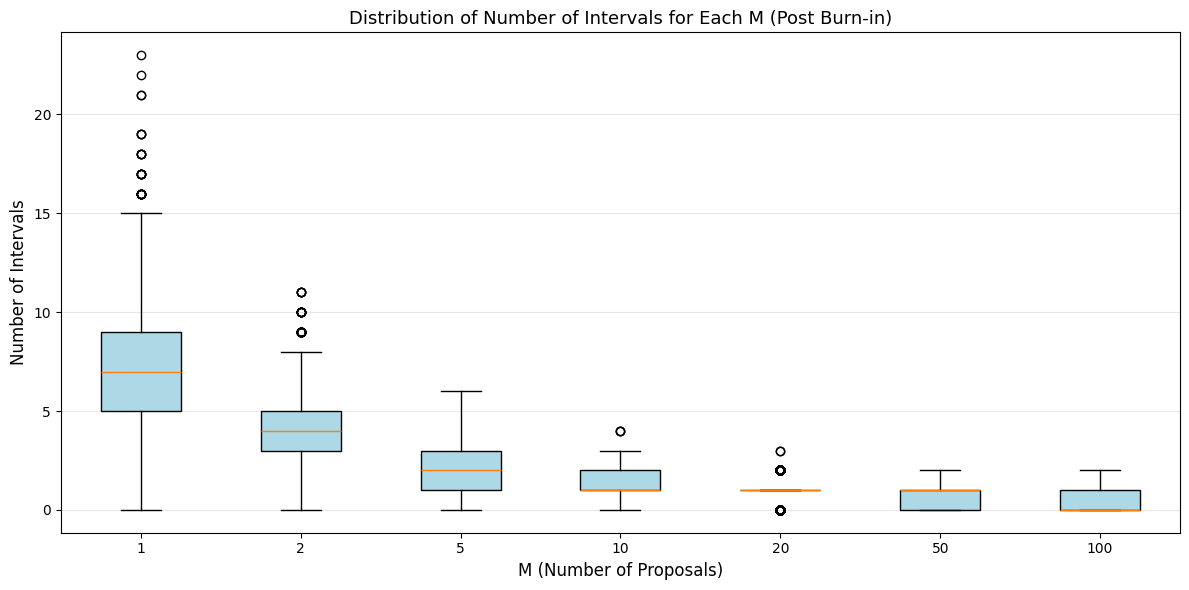


Detailed Statistics (Post Burn-in):
M          Min        Q1         Median     Q3         Max       
1          0          5          7          9          23        
2          0          3          4          5          11        
5          0          1          2          3          6         
10         0          1          1          2          4         
20         0          1          1          1          3         
50         0          0          1          1          2         
100        0          0          0          1          2         


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for box plot (post burn-in only)
box_data = [results['intervals'][M][burn_in:] for M in results['M_values']]
labels = [str(M) for M in results['M_values']]

bp = ax.boxplot(box_data, labels=labels, patch_artist=True)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Number of Intervals', fontsize=12)
ax.set_title('Distribution of Number of Intervals for Each M (Post Burn-in)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Compute some additional statistics
print("\nDetailed Statistics (Post Burn-in):")
print("="*80)
print(f"{'M':<10} {'Min':<10} {'Q1':<10} {'Median':<10} {'Q3':<10} {'Max':<10}")
print("="*80)
for M in results['M_values']:
    intervals_post = results['intervals'][M][burn_in:]
    q1, med, q3 = np.percentile(intervals_post, [25, 50, 75])
    print(f"{M:<10} {int(np.min(intervals_post)):<10} {int(q1):<10} {int(med):<10} {int(q3):<10} {int(np.max(intervals_post)):<10}")
print("="*80)


## Run MESS with Angular Distance

Now run the same experiment with MESS using angular distance and linear programming to compute the transition matrix.


In [9]:
# Filter M_values to only use M <= 100 for angular and euclidean experiments
M_values_filtered = [M for M in M_values if M <= 100]

# Initialize results dictionaries for angular and euclidean variants
results_angular = {
    'M_values': M_values_filtered,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

In [12]:
# Run experiments for each M value with angular distance
lambda_value = 0.05
for M in M_values_filtered:
    print(f"\nRunning MESS (angular) with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, num_data))
    chain[0] = x0.copy()  # Initial state
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True, 
                                       distance_metric='angular', lam=lambda_value)
        chain[t + 1] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in + 1:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results_angular['mean_intervals'].append(mean_intervals)
    results_angular['std_intervals'].append(std_intervals)
    results_angular['median_intervals'].append(median_intervals)
    results_angular['chains'][M] = chain
    results_angular['intervals'][M] = intervals
    results_angular['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment (Angular Distance) completed!")


Running MESS (angular) with M = 1...
  Mean intervals: 6.9980 ± 3.3884
  Median intervals: 7.0
  Time: 11.18 seconds

Running MESS (angular) with M = 2...
  Mean intervals: 3.9660 ± 1.9924
  Median intervals: 4.0
  Time: 12.07 seconds

Running MESS (angular) with M = 5...
  Mean intervals: 2.0512 ± 1.0771
  Median intervals: 2.0
  Time: 11.86 seconds

Running MESS (angular) with M = 10...
  Mean intervals: 1.2901 ± 0.7481
  Median intervals: 1.0
  Time: 11.21 seconds

Running MESS (angular) with M = 20...


KeyboardInterrupt: 

In [10]:
# Store results for MESS with euclidean distance
results_euclidean = {
    'M_values': M_values_filtered,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

# Run experiments for each M value with euclidean distance
for M in M_values_filtered:
    print(f"\nRunning MESS (euclidean) with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, num_data))
    chain[0] = x0.copy()  # Initial state
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True, 
                                       distance_metric='euclidean', lam=0.05)
        chain[t + 1] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in + 1:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results_euclidean['mean_intervals'].append(mean_intervals)
    results_euclidean['std_intervals'].append(std_intervals)
    results_euclidean['median_intervals'].append(median_intervals)
    results_euclidean['chains'][M] = chain
    results_euclidean['intervals'][M] = intervals
    results_euclidean['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment (Euclidean Distance) completed!")


Running MESS (euclidean) with M = 1...
  Mean intervals: 6.9980 ± 3.3884
  Median intervals: 7.0
  Time: 9.39 seconds

Running MESS (euclidean) with M = 2...
  Mean intervals: 3.9660 ± 1.9924
  Median intervals: 4.0
  Time: 9.41 seconds

Running MESS (euclidean) with M = 10...
  Mean intervals: 1.3265 ± 0.7679
  Median intervals: 1.0
  Time: 10.66 seconds

Running MESS (euclidean) with M = 20...
  Mean intervals: 0.8715 ± 0.5893
  Median intervals: 1.0
  Time: 11.74 seconds

Experiment (Euclidean Distance) completed!


## Comprehensive Comparison: Three MESS Variants

Compare the number of intervals for:
1. MESS Uniform (no LP, random transition matrix)
2. MESS Angular Distance (LP + angular metric)
3. MESS Euclidean Distance (LP + euclidean metric)

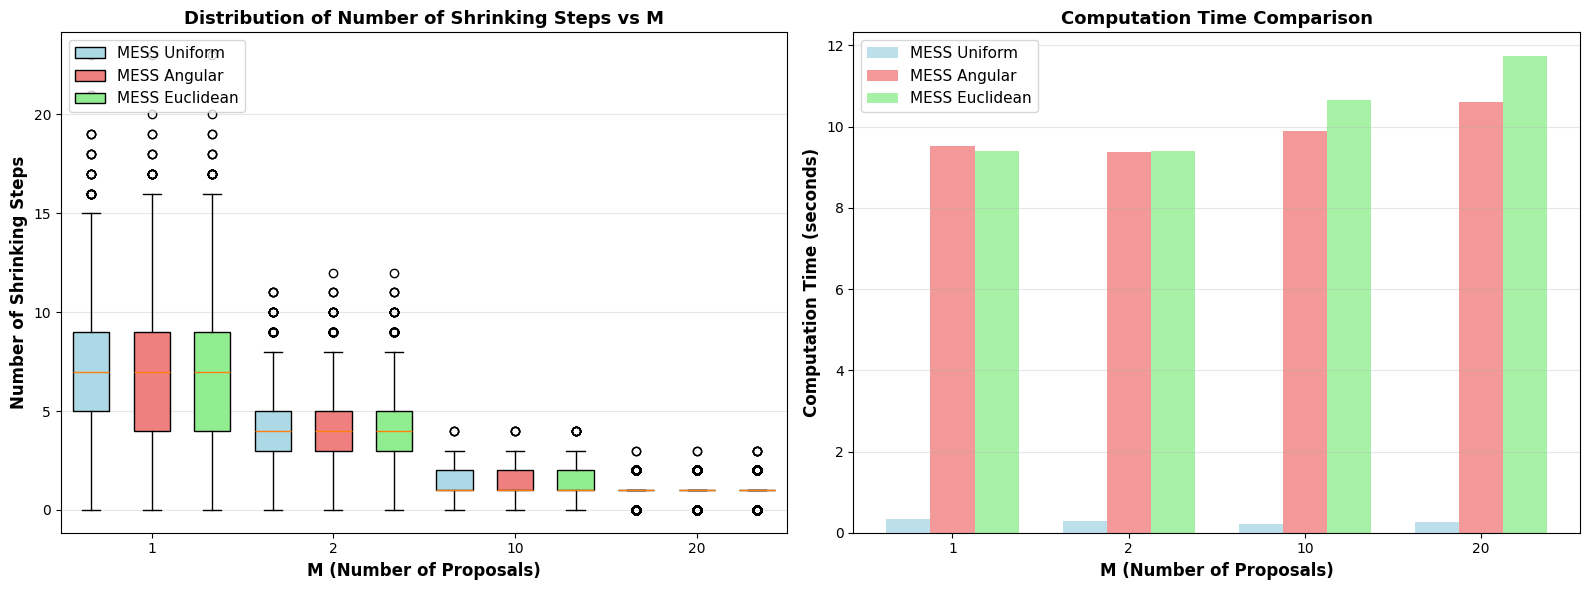


Detailed Comparison Table:
M        Method             Mean         Median       Std Dev      Min          Max          Time (s)    
1        MESS Uniform       6.9676       7.0          3.3753       0            23           0.3478      
         MESS Angular       6.9980       7.0          3.3884       0            23           9.5341      
         MESS Euclidean     6.9980       7.0          3.3884       0            23           9.3950      
--------------------------------------------------------------------------------------------------------------------------------------------
2        MESS Uniform       4.0096       4.0          1.9726       0            11           0.2992      
         MESS Angular       3.9660       4.0          1.9924       0            12           9.3720      
         MESS Euclidean     3.9660       4.0          1.9924       0            12           9.4073      
-----------------------------------------------------------------------------------------

In [11]:
# Prepare data for the 1x2 comparison figure
# Filter uniform results to match angular/euclidean results (M <= 100 only)
idx_uniform_filtered = [i for i, M in enumerate(results['M_values']) if M <= 100]
M_compare = np.array([M for M in results['M_values'] if M <= 100])

# Create the 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: Number of Intervals Distribution =====
ax = axes[0]

# Prepare boxplot data for all three methods
uniform_box_data = [results['intervals'][M][burn_in:] for M in M_compare]
angular_box_data = [results_angular['intervals'][M][burn_in + 1:] for M in M_compare]
euclidean_box_data = [results_euclidean['intervals'][M][burn_in + 1:] for M in M_compare]

# Positions for the boxplots
num_M = len(M_compare)
positions_uniform = np.arange(num_M) * 3
positions_angular = positions_uniform + 1
positions_euclidean = positions_uniform + 2

# Create boxplots
bp1 = ax.boxplot(uniform_box_data, positions=positions_uniform, widths=0.6, 
                  patch_artist=True, label='MESS Uniform')
bp2 = ax.boxplot(angular_box_data, positions=positions_angular, widths=0.6, 
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_box_data, positions=positions_euclidean, widths=0.6, 
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
for patch in bp3['boxes']:
    patch.set_facecolor('lightgreen')

# Set x-axis labels
ax.set_xticks(positions_uniform + 1)
ax.set_xticklabels([str(M) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shrinking Steps', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Number of Shrinking Steps vs M', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# ===== RIGHT PLOT: Computation Time =====
ax = axes[1]

# Get times for all methods
uniform_times_filtered = np.array([results['times'][i] for i in idx_uniform_filtered])
angular_times = np.array(results_angular['times'])
euclidean_times = np.array(results_euclidean['times'])

x_pos = np.arange(num_M)
width = 0.25

ax.bar(x_pos - width, uniform_times_filtered, width, label='MESS Uniform', 
       color='lightblue', alpha=0.8)
ax.bar(x_pos, angular_times, width, label='MESS Angular', 
       color='lightcoral', alpha=0.8)
ax.bar(x_pos + width, euclidean_times, width, label='MESS Euclidean', 
       color='lightgreen', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(M) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Computation Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Computation Time Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\nDetailed Comparison Table:")
print("="*140)
print(f"{'M':<8} {'Method':<18} {'Mean':<12} {'Median':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12} {'Time (s)':<12}")
print("="*140)
for i, M in enumerate(M_compare):
    # Uniform
    uniform_data = results['intervals'][M][burn_in:]
    print(f"{M:<8} {'MESS Uniform':<18} {np.mean(uniform_data):<12.4f} {np.median(uniform_data):<12.1f} {np.std(uniform_data):<12.4f} {np.min(uniform_data):<12} {np.max(uniform_data):<12} {uniform_times_filtered[i]:<12.4f}")
    
    # Angular
    angular_data = results_angular['intervals'][M][burn_in + 1:]
    print(f"{'':<8} {'MESS Angular':<18} {np.mean(angular_data):<12.4f} {np.median(angular_data):<12.1f} {np.std(angular_data):<12.4f} {np.min(angular_data):<12} {np.max(angular_data):<12} {angular_times[i]:<12.4f}")
    
    # Euclidean
    euclidean_data = results_euclidean['intervals'][M][burn_in + 1:]
    print(f"{'':<8} {'MESS Euclidean':<18} {np.mean(euclidean_data):<12.4f} {np.median(euclidean_data):<12.1f} {np.std(euclidean_data):<12.4f} {np.min(euclidean_data):<12} {np.max(euclidean_data):<12} {euclidean_times[i]:<12.4f}")
    
    print("-"*140)
# print("="*140)

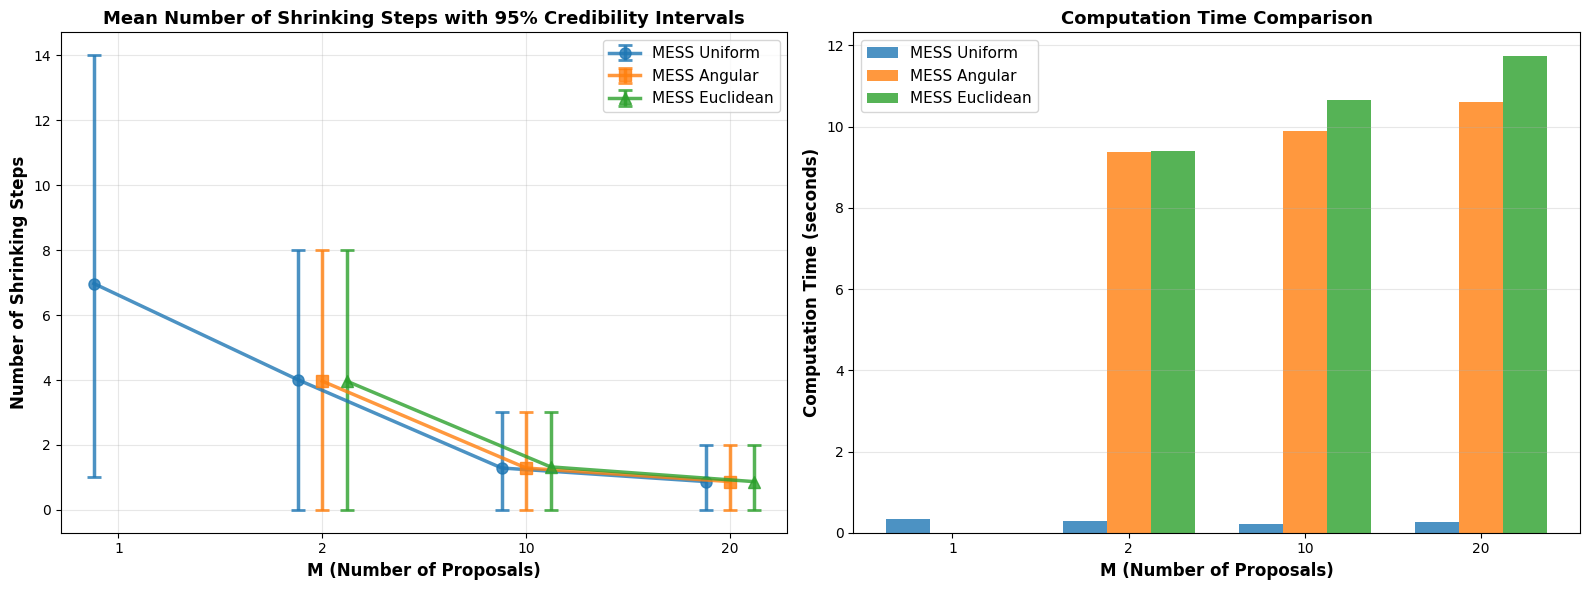


Detailed Comparison Table:
M        Method             Mean         Median       Std Dev      Min          Max          Time (s)    
1        MESS Uniform       6.9676       7.0          3.3753       0            23           0.3478      
--------------------------------------------------------------------------------------------------------------------------------------------
2        MESS Uniform       4.0096       4.0          1.9726       0            11           0.2992      
         MESS Angular       3.9660       4.0          1.9924       0            12           9.3720      
         MESS Euclidean     3.9660       4.0          1.9924       0            12           9.4073      
--------------------------------------------------------------------------------------------------------------------------------------------
10       MESS Uniform       1.2924       1.0          0.7513       0            4            0.2252      
         MESS Angular       1.2901       1.0          

In [17]:
# Prepare data for the 1x2 comparison figure
# Filter uniform results to match angular/euclidean results (M <= 100 only), but include M=1
idx_uniform_filtered = [i for i, M in enumerate(results['M_values']) if M == 1 or M <= 100]
M_compare = np.array([M for M in results['M_values'] if M == 1 or M <= 100])

# Create the 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: Number of Intervals with Credibility Intervals =====
ax = axes[0]

# Compute means and 95% credibility intervals for all three methods
uniform_means = []
uniform_ci_lower = []
uniform_ci_upper = []

angular_means = []
angular_ci_lower = []
angular_ci_upper = []

euclidean_means = []
euclidean_ci_lower = []
euclidean_ci_upper = []

for M in M_compare:
    # Uniform
    uniform_data = results['intervals'][M][burn_in:]
    uniform_means.append(np.mean(uniform_data))
    uniform_ci_lower.append(np.percentile(uniform_data, 2.5))
    uniform_ci_upper.append(np.percentile(uniform_data, 97.5))
    
    # Angular (only for M > 1)
    if M > 1:
        angular_data = results_angular['intervals'][M][burn_in + 1:]
        angular_means.append(np.mean(angular_data))
        angular_ci_lower.append(np.percentile(angular_data, 2.5))
        angular_ci_upper.append(np.percentile(angular_data, 97.5))
    else:
        angular_means.append(np.nan)
        angular_ci_lower.append(np.nan)
        angular_ci_upper.append(np.nan)
    
    # Euclidean (only for M > 1)
    if M > 1:
        euclidean_data = results_euclidean['intervals'][M][burn_in + 1:]
        euclidean_means.append(np.mean(euclidean_data))
        euclidean_ci_lower.append(np.percentile(euclidean_data, 2.5))
        euclidean_ci_upper.append(np.percentile(euclidean_data, 97.5))
    else:
        euclidean_means.append(np.nan)
        euclidean_ci_lower.append(np.nan)
        euclidean_ci_upper.append(np.nan)

# Convert to arrays for error calculation
uniform_means = np.array(uniform_means)
uniform_ci_lower = np.array(uniform_ci_lower)
uniform_ci_upper = np.array(uniform_ci_upper)
uniform_error = [uniform_means - uniform_ci_lower, uniform_ci_upper - uniform_means]

angular_means = np.array(angular_means)
angular_ci_lower = np.array(angular_ci_lower)
angular_ci_upper = np.array(angular_ci_upper)
angular_error = [angular_means - angular_ci_lower, angular_ci_upper - angular_means]

euclidean_means = np.array(euclidean_means)
euclidean_ci_lower = np.array(euclidean_ci_lower)
euclidean_ci_upper = np.array(euclidean_ci_upper)
euclidean_error = [euclidean_means - euclidean_ci_lower, euclidean_ci_upper - euclidean_means]

# Create x-positions for separated error bars
num_M = len(M_compare)
x_base = np.arange(num_M)
offset = 0.12

# Plot the curves with error bars - separated
ax.errorbar(x_base - offset, uniform_means, yerr=uniform_error, fmt='o-', linewidth=2.5, markersize=8,
            label='MESS Uniform', color='#1f77b4', capsize=5, capthick=2, alpha=0.8)
ax.errorbar(x_base, angular_means, yerr=angular_error, fmt='s-', linewidth=2.5, markersize=8,
            label='MESS Angular', color='#ff7f0e', capsize=5, capthick=2, alpha=0.8)
ax.errorbar(x_base + offset, euclidean_means, yerr=euclidean_error, fmt='^-', linewidth=2.5, markersize=8,
            label='MESS Euclidean', color='#2ca02c', capsize=5, capthick=2, alpha=0.8)

ax.set_xticks(x_base)
ax.set_xticklabels([str(int(M)) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shrinking Steps', fontsize=12, fontweight='bold')
ax.set_title('Mean Number of Shrinking Steps with 95% Credibility Intervals', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

# ===== RIGHT PLOT: Computation Time =====
ax = axes[1]

# Get times for all methods
uniform_times_filtered = np.array([results['times'][i] for i in idx_uniform_filtered])
angular_times = []
euclidean_times = []

for M in M_compare:
    if M > 1:
        # Find index of M in M_values_filtered
        idx = list(M_values_filtered).index(M)
        angular_times.append(results_angular['times'][idx])
        euclidean_times.append(results_euclidean['times'][idx])
    else:
        angular_times.append(np.nan)
        euclidean_times.append(np.nan)

angular_times = np.array(angular_times)
euclidean_times = np.array(euclidean_times)

x_pos = np.arange(num_M)
width = 0.25

ax.bar(x_pos - width, uniform_times_filtered, width, label='MESS Uniform', 
       color='#1f77b4', alpha=0.8)
ax.bar(x_pos, angular_times, width, label='MESS Angular', 
       color='#ff7f0e', alpha=0.8)
ax.bar(x_pos + width, euclidean_times, width, label='MESS Euclidean', 
       color='#2ca02c', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(int(M)) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Computation Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Computation Time Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\nDetailed Comparison Table:")
print("="*140)
print(f"{'M':<8} {'Method':<18} {'Mean':<12} {'Median':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12} {'Time (s)':<12}")
print("="*140)
for i, M in enumerate(M_compare):
    # Uniform
    uniform_data = results['intervals'][M][burn_in:]
    print(f"{M:<8} {'MESS Uniform':<18} {np.mean(uniform_data):<12.4f} {np.median(uniform_data):<12.1f} {np.std(uniform_data):<12.4f} {np.min(uniform_data):<12} {np.max(uniform_data):<12} {uniform_times_filtered[i]:<12.4f}")
    
    # Angular
    if M > 1:
        angular_data = results_angular['intervals'][M][burn_in + 1:]
        idx_angular = list(M_values_filtered).index(M)
        print(f"{'':<8} {'MESS Angular':<18} {np.mean(angular_data):<12.4f} {np.median(angular_data):<12.1f} {np.std(angular_data):<12.4f} {np.min(angular_data):<12} {np.max(angular_data):<12} {results_angular['times'][idx_angular]:<12.4f}")
    
    # Euclidean
    if M > 1:
        euclidean_data = results_euclidean['intervals'][M][burn_in + 1:]
        idx_euclidean = list(M_values_filtered).index(M)
        print(f"{'':<8} {'MESS Euclidean':<18} {np.mean(euclidean_data):<12.4f} {np.median(euclidean_data):<12.1f} {np.std(euclidean_data):<12.4f} {np.min(euclidean_data):<12} {np.max(euclidean_data):<12} {results_euclidean['times'][idx_euclidean]:<12.4f}")
    
    print("-"*140)
print("="*140)

In [18]:
# save the last figure to file
fig.savefig('mess_comparison_intervals_times.pdf', dpi=600)

## Compute Effective Sample Size (ESS) for All Methods

Estimate the effective sample size for each coordinate and each method across all M values.


In [14]:
max_lag = 1500

# Compute ESS for all methods and all M values
ess_results = {
    'M_values': M_compare,
    'uniform_ess_mean': [],
    'uniform_ess_ci_lower': [],
    'uniform_ess_ci_upper': [],
    'angular_ess_mean': [],
    'angular_ess_ci_lower': [],
    'angular_ess_ci_upper': [],
    'euclidean_ess_mean': [],
    'euclidean_ess_ci_lower': [],
    'euclidean_ess_ci_upper': [],
}

# Process each M value
for M in M_compare:
    print(f"\nComputing ESS for M = {M}...")
    
    # Uniform
    chain_uniform = results['chains'][M][burn_in:, :]  # Post burn-in
    ess_uniform = estimate_effective_sample_size(chain_uniform, max_lag=max_lag)
    ess_results['uniform_ess_mean'].append(np.mean(ess_uniform))
    ess_results['uniform_ess_ci_lower'].append(np.percentile(ess_uniform, 2.5))
    ess_results['uniform_ess_ci_upper'].append(np.percentile(ess_uniform, 97.5))
    print(f"  MESS Uniform - Mean ESS: {np.mean(ess_uniform):.2f}, 95% CI: [{np.percentile(ess_uniform, 2.5):.2f}, {np.percentile(ess_uniform, 97.5):.2f}]")
    
    # Angular (only for M > 1)
    if M > 1:
        chain_angular = results_angular['chains'][M][burn_in+1:, :]  # Post burn-in
        ess_angular = estimate_effective_sample_size(chain_angular, max_lag=max_lag)
        ess_results['angular_ess_mean'].append(np.mean(ess_angular))
        ess_results['angular_ess_ci_lower'].append(np.percentile(ess_angular, 2.5))
        ess_results['angular_ess_ci_upper'].append(np.percentile(ess_angular, 97.5))
        print(f"  MESS Angular - Mean ESS: {np.mean(ess_angular):.2f}, 95% CI: [{np.percentile(ess_angular, 2.5):.2f}, {np.percentile(ess_angular, 97.5):.2f}]")
    else:
        ess_results['angular_ess_mean'].append(np.nan)
        ess_results['angular_ess_ci_lower'].append(np.nan)
        ess_results['angular_ess_ci_upper'].append(np.nan)
    
    # Euclidean (only for M > 1)
    if M > 1:
        chain_euclidean = results_euclidean['chains'][M][burn_in+1:, :]  # Post burn-in
        ess_euclidean = estimate_effective_sample_size(chain_euclidean, max_lag=max_lag)
        ess_results['euclidean_ess_mean'].append(np.mean(ess_euclidean))
        ess_results['euclidean_ess_ci_lower'].append(np.percentile(ess_euclidean, 2.5))
        ess_results['euclidean_ess_ci_upper'].append(np.percentile(ess_euclidean, 97.5))
        print(f"  MESS Euclidean - Mean ESS: {np.mean(ess_euclidean):.2f}, 95% CI: [{np.percentile(ess_euclidean, 2.5):.2f}, {np.percentile(ess_euclidean, 97.5):.2f}]")
    else:
        ess_results['euclidean_ess_mean'].append(np.nan)
        ess_results['euclidean_ess_ci_lower'].append(np.nan)
        ess_results['euclidean_ess_ci_upper'].append(np.nan)

print("\n" + "="*80)
print("ESS computation completed!")



Computing ESS for M = 1...
Estimating ESS for each parameter.
  MESS Uniform - Mean ESS: 36.64, 95% CI: [10.79, 76.80]

Computing ESS for M = 2...
Estimating ESS for each parameter.
  MESS Uniform - Mean ESS: 40.52, 95% CI: [13.37, 74.87]
Estimating ESS for each parameter.
  MESS Angular - Mean ESS: 37.90, 95% CI: [11.47, 78.76]
Estimating ESS for each parameter.
  MESS Euclidean - Mean ESS: 37.90, 95% CI: [11.47, 78.76]

Computing ESS for M = 10...
Estimating ESS for each parameter.
  MESS Uniform - Mean ESS: 35.22, 95% CI: [12.87, 70.12]
Estimating ESS for each parameter.
  MESS Angular - Mean ESS: 34.22, 95% CI: [10.56, 78.55]
Estimating ESS for each parameter.
  MESS Euclidean - Mean ESS: 32.34, 95% CI: [12.23, 67.97]

Computing ESS for M = 20...
Estimating ESS for each parameter.
  MESS Uniform - Mean ESS: 35.46, 95% CI: [13.51, 77.33]
Estimating ESS for each parameter.
  MESS Angular - Mean ESS: 36.32, 95% CI: [12.74, 69.68]
Estimating ESS for each parameter.
  MESS Euclidean - 

## Plot ESS Comparison with Error Bars

Compare the effective sample size distributions for all three MESS variants with separated error bars.


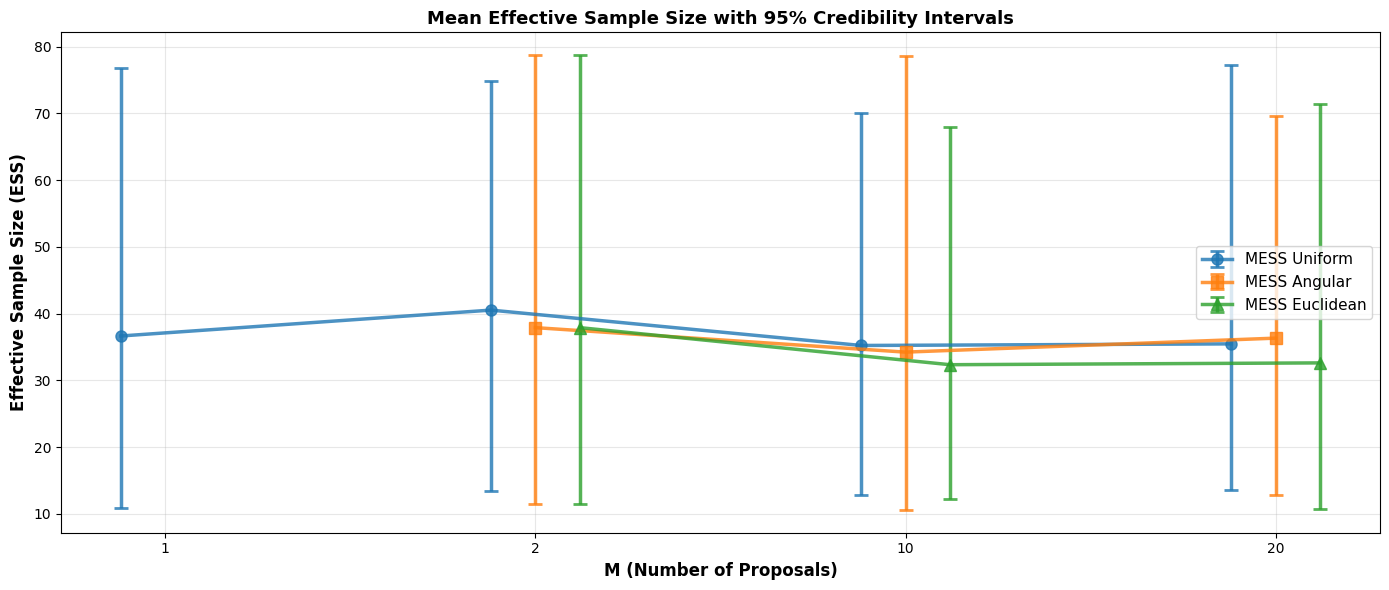


Detailed ESS Comparison Table:
M        Method             Mean ESS        95% CI Lower    95% CI Upper   
1        MESS Uniform       36.64           10.79           76.80          
------------------------------------------------------------------------------------------------------------------------
2        MESS Uniform       40.52           13.37           74.87          
         MESS Angular       37.90           11.47           78.76          
         MESS Euclidean     37.90           11.47           78.76          
------------------------------------------------------------------------------------------------------------------------
10       MESS Uniform       35.22           12.87           70.12          
         MESS Angular       34.22           10.56           78.55          
         MESS Euclidean     32.34           12.23           67.97          
----------------------------------------------------------------------------------------------------------------------

In [15]:
# Convert ESS results to arrays for plotting
uniform_ess_means = np.array(ess_results['uniform_ess_mean'])
uniform_ess_ci_lower = np.array(ess_results['uniform_ess_ci_lower'])
uniform_ess_ci_upper = np.array(ess_results['uniform_ess_ci_upper'])
uniform_ess_error = [uniform_ess_means - uniform_ess_ci_lower, uniform_ess_ci_upper - uniform_ess_means]

angular_ess_means = np.array(ess_results['angular_ess_mean'])
angular_ess_ci_lower = np.array(ess_results['angular_ess_ci_lower'])
angular_ess_ci_upper = np.array(ess_results['angular_ess_ci_upper'])
angular_ess_error = [angular_ess_means - angular_ess_ci_lower, angular_ess_ci_upper - angular_ess_means]

euclidean_ess_means = np.array(ess_results['euclidean_ess_mean'])
euclidean_ess_ci_lower = np.array(ess_results['euclidean_ess_ci_lower'])
euclidean_ess_ci_upper = np.array(ess_results['euclidean_ess_ci_upper'])
euclidean_ess_error = [euclidean_ess_means - euclidean_ess_ci_lower, euclidean_ess_ci_upper - euclidean_ess_means]

# Create figure for ESS comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Create x-positions for separated error bars
num_M = len(M_compare)
x_base = np.arange(num_M)
offset = 0.12

# Plot the curves with error bars - separated
ax.errorbar(x_base - offset, uniform_ess_means, yerr=uniform_ess_error, fmt='o-', linewidth=2.5, markersize=8,
            label='MESS Uniform', color='#1f77b4', capsize=5, capthick=2, alpha=0.8)
ax.errorbar(x_base, angular_ess_means, yerr=angular_ess_error, fmt='s-', linewidth=2.5, markersize=8,
            label='MESS Angular', color='#ff7f0e', capsize=5, capthick=2, alpha=0.8)
ax.errorbar(x_base + offset, euclidean_ess_means, yerr=euclidean_ess_error, fmt='^-', linewidth=2.5, markersize=8,
            label='MESS Euclidean', color='#2ca02c', capsize=5, capthick=2, alpha=0.8)

ax.set_xticks(x_base)
ax.set_xticklabels([str(int(M)) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effective Sample Size (ESS)', fontsize=12, fontweight='bold')
ax.set_title('Mean Effective Sample Size with 95% Credibility Intervals', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed ESS comparison table
print("\nDetailed ESS Comparison Table:")
print("="*120)
print(f"{'M':<8} {'Method':<18} {'Mean ESS':<15} {'95% CI Lower':<15} {'95% CI Upper':<15}")
print("="*120)
for i, M in enumerate(M_compare):
    # Uniform
    print(f"{M:<8} {'MESS Uniform':<18} {uniform_ess_means[i]:<15.2f} {uniform_ess_ci_lower[i]:<15.2f} {uniform_ess_ci_upper[i]:<15.2f}")
    
    # Angular
    if M > 1:
        print(f"{'':<8} {'MESS Angular':<18} {angular_ess_means[i]:<15.2f} {angular_ess_ci_lower[i]:<15.2f} {angular_ess_ci_upper[i]:<15.2f}")
    
    # Euclidean
    if M > 1:
        print(f"{'':<8} {'MESS Euclidean':<18} {euclidean_ess_means[i]:<15.2f} {euclidean_ess_ci_lower[i]:<15.2f} {euclidean_ess_ci_upper[i]:<15.2f}")
    
    print("-"*120)
print("="*120)


## ESS Boxplot Comparison

Visualize the distribution of effective sample sizes across parameters using boxplots for each M value.


Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.


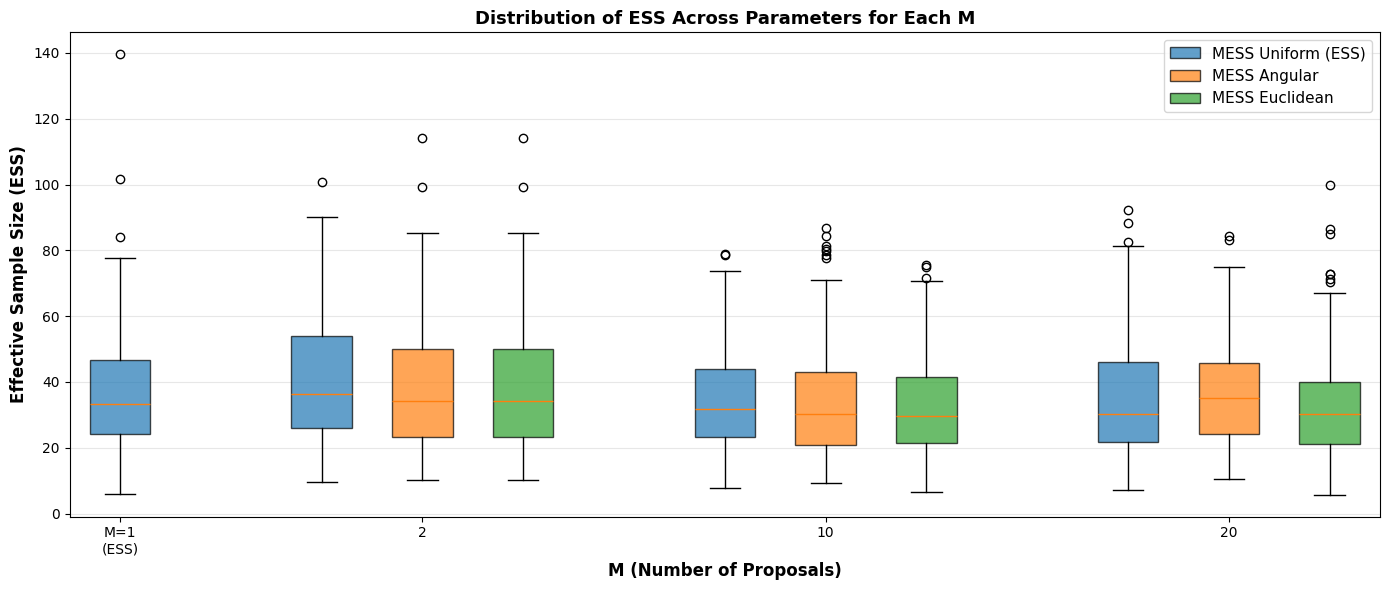

In [22]:
# Prepare boxplot data for ESS comparison
# Include all M values, but M=1 will only have uniform
uniform_ess_box = []
angular_ess_box = []
euclidean_ess_box = []
M_box_compare = []  # Track which M values we have data for

for M in M_compare:
    # Uniform (available for all M)
    chain_uniform = results['chains'][M][burn_in:, :]
    ess_uniform = estimate_effective_sample_size(chain_uniform)
    uniform_ess_box.append(ess_uniform)
    
    # Angular (only for M > 1)
    if M > 1:
        chain_angular = results_angular['chains'][M][burn_in+1:, :]
        ess_angular = estimate_effective_sample_size(chain_angular)
        angular_ess_box.append(ess_angular)
        
        # Euclidean (only for M > 1)
        chain_euclidean = results_euclidean['chains'][M][burn_in+1:, :]
        ess_euclidean = estimate_effective_sample_size(chain_euclidean)
        euclidean_ess_box.append(ess_euclidean)
    
    M_box_compare.append(M)

# Create figure with boxplots
fig, ax = plt.subplots(figsize=(14, 6))

# Positions for the boxplots
# For M=1: only uniform at position 0
# For M>1: uniform, angular, euclidean at positions 1, 2, 3 (and repeat pattern)
positions_uniform = []
positions_angular = []
positions_euclidean = []

pos_counter = 0
for i, M in enumerate(M_box_compare):
    positions_uniform.append(pos_counter)
    pos_counter += 1
    
    if M > 1:
        positions_angular.append(pos_counter)
        pos_counter += 1
        positions_euclidean.append(pos_counter)
        pos_counter += 1
    
    pos_counter += 1  # Add gap between M values

# Create boxplots
bp1 = ax.boxplot(uniform_ess_box, positions=positions_uniform, widths=0.6,
                  patch_artist=True, label='MESS Uniform (ESS)')
bp2 = ax.boxplot(angular_ess_box, positions=positions_angular, widths=0.6,
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_ess_box, positions=positions_euclidean, widths=0.6,
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# Set x-axis labels
x_ticks = []
x_labels = []
for i, M in enumerate(M_box_compare):
    if M == 1:
        x_ticks.append(positions_uniform[i])
        x_labels.append(f"M={int(M)}\n(ESS)")
    else:
        # Get average position for the three methods
        avg_pos = (positions_uniform[i] + positions_angular[len(positions_angular)-len(M_box_compare)+i] + positions_euclidean[len(positions_euclidean)-len(M_box_compare)+i]) / 3
        x_ticks.append(avg_pos)
        x_labels.append(str(int(M)))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effective Sample Size (ESS)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of ESS Across Parameters for Each M', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Mean Squared Jumping Distance (MSJD) Comparison

Compute and compare the mean squared jumping distance for all methods across M values.


In [20]:
# Compute MSJD for all methods and all M values
msjd_results = {
    'M_values': M_compare,
    'uniform_msjd_mean': [],
    'uniform_msjd_ci_lower': [],
    'uniform_msjd_ci_upper': [],
    'angular_msjd_mean': [],
    'angular_msjd_ci_lower': [],
    'angular_msjd_ci_upper': [],
    'euclidean_msjd_mean': [],
    'euclidean_msjd_ci_lower': [],
    'euclidean_msjd_ci_upper': [],
}

# Process each M value
for M in M_compare:
    print(f"\nComputing MSJD for M = {M}...")
    
    # Uniform
    chain_uniform = results['chains'][M][burn_in:, :]  # Post burn-in
    msjd_uniform = compute_mean_squared_jumping_distance(chain_uniform)
    msjd_results['uniform_msjd_mean'].append(np.mean(msjd_uniform))
    msjd_results['uniform_msjd_ci_lower'].append(np.percentile(msjd_uniform, 2.5))
    msjd_results['uniform_msjd_ci_upper'].append(np.percentile(msjd_uniform, 97.5))
    print(f"  MESS Uniform - Mean MSJD: {np.mean(msjd_uniform):.4f}, 95% CI: [{np.percentile(msjd_uniform, 2.5):.4f}, {np.percentile(msjd_uniform, 97.5):.4f}]")
    
    # Angular (only for M > 1)
    if M > 1:
        chain_angular = results_angular['chains'][M][burn_in+1:, :]  # Post burn-in
        msjd_angular = compute_mean_squared_jumping_distance(chain_angular)
        msjd_results['angular_msjd_mean'].append(np.mean(msjd_angular))
        msjd_results['angular_msjd_ci_lower'].append(np.percentile(msjd_angular, 2.5))
        msjd_results['angular_msjd_ci_upper'].append(np.percentile(msjd_angular, 97.5))
        print(f"  MESS Angular - Mean MSJD: {np.mean(msjd_angular):.4f}, 95% CI: [{np.percentile(msjd_angular, 2.5):.4f}, {np.percentile(msjd_angular, 97.5):.4f}]")
    else:
        msjd_results['angular_msjd_mean'].append(np.nan)
        msjd_results['angular_msjd_ci_lower'].append(np.nan)
        msjd_results['angular_msjd_ci_upper'].append(np.nan)
    
    # Euclidean (only for M > 1)
    if M > 1:
        chain_euclidean = results_euclidean['chains'][M][burn_in+1:, :]  # Post burn-in
        msjd_euclidean = compute_mean_squared_jumping_distance(chain_euclidean)
        msjd_results['euclidean_msjd_mean'].append(np.mean(msjd_euclidean))
        msjd_results['euclidean_msjd_ci_lower'].append(np.percentile(msjd_euclidean, 2.5))
        msjd_results['euclidean_msjd_ci_upper'].append(np.percentile(msjd_euclidean, 97.5))
        print(f"  MESS Euclidean - Mean MSJD: {np.mean(msjd_euclidean):.4f}, 95% CI: [{np.percentile(msjd_euclidean, 2.5):.4f}, {np.percentile(msjd_euclidean, 97.5):.4f}]")
    else:
        msjd_results['euclidean_msjd_mean'].append(np.nan)
        msjd_results['euclidean_msjd_ci_lower'].append(np.nan)
        msjd_results['euclidean_msjd_ci_upper'].append(np.nan)

print("\n" + "="*80)
print("MSJD computation completed!")



Computing MSJD for M = 1...
  MESS Uniform - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0011]

Computing MSJD for M = 2...
  MESS Uniform - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0011]
  MESS Angular - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0011]
  MESS Euclidean - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0011]

Computing MSJD for M = 10...
  MESS Uniform - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0010]
  MESS Angular - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0011]
  MESS Euclidean - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0011]

Computing MSJD for M = 20...
  MESS Uniform - Mean MSJD: 0.0008, 95% CI: [0.0007, 0.0010]
  MESS Angular - Mean MSJD: 0.0009, 95% CI: [0.0007, 0.0010]
  MESS Euclidean - Mean MSJD: 0.0008, 95% CI: [0.0007, 0.0010]

MSJD computation completed!


## Plot MSJD Comparison with Error Bars

Visualize the mean squared jumping distance with separated error bars for all three MESS variants.


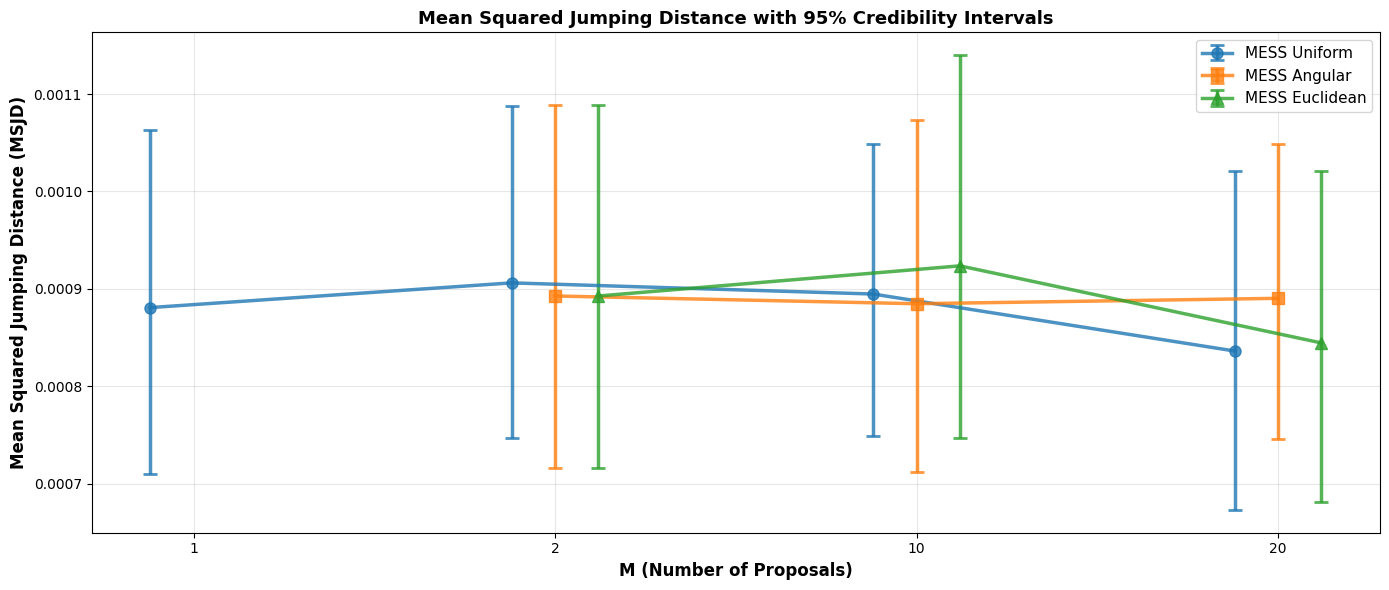


Detailed MSJD Comparison Table:
M        Method             Mean MSJD       95% CI Lower    95% CI Upper   
1        MESS Uniform       0.0009          0.0007          0.0011         
------------------------------------------------------------------------------------------------------------------------
2        MESS Uniform       0.0009          0.0007          0.0011         
         MESS Angular       0.0009          0.0007          0.0011         
         MESS Euclidean     0.0009          0.0007          0.0011         
------------------------------------------------------------------------------------------------------------------------
10       MESS Uniform       0.0009          0.0007          0.0010         
         MESS Angular       0.0009          0.0007          0.0011         
         MESS Euclidean     0.0009          0.0007          0.0011         
---------------------------------------------------------------------------------------------------------------------

In [21]:
# Convert MSJD results to arrays for plotting
uniform_msjd_means = np.array(msjd_results['uniform_msjd_mean'])
uniform_msjd_ci_lower = np.array(msjd_results['uniform_msjd_ci_lower'])
uniform_msjd_ci_upper = np.array(msjd_results['uniform_msjd_ci_upper'])
uniform_msjd_error = [uniform_msjd_means - uniform_msjd_ci_lower, uniform_msjd_ci_upper - uniform_msjd_means]

angular_msjd_means = np.array(msjd_results['angular_msjd_mean'])
angular_msjd_ci_lower = np.array(msjd_results['angular_msjd_ci_lower'])
angular_msjd_ci_upper = np.array(msjd_results['angular_msjd_ci_upper'])
angular_msjd_error = [angular_msjd_means - angular_msjd_ci_lower, angular_msjd_ci_upper - angular_msjd_means]

euclidean_msjd_means = np.array(msjd_results['euclidean_msjd_mean'])
euclidean_msjd_ci_lower = np.array(msjd_results['euclidean_msjd_ci_lower'])
euclidean_msjd_ci_upper = np.array(msjd_results['euclidean_msjd_ci_upper'])
euclidean_msjd_error = [euclidean_msjd_means - euclidean_msjd_ci_lower, euclidean_msjd_ci_upper - euclidean_msjd_means]

# Create figure for MSJD comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Create x-positions for separated error bars
num_M = len(M_compare)
x_base = np.arange(num_M)
offset = 0.12

# Plot the curves with error bars - separated
ax.errorbar(x_base - offset, uniform_msjd_means, yerr=uniform_msjd_error, fmt='o-', linewidth=2.5, markersize=8,
            label='MESS Uniform', color='#1f77b4', capsize=5, capthick=2, alpha=0.8)
ax.errorbar(x_base, angular_msjd_means, yerr=angular_msjd_error, fmt='s-', linewidth=2.5, markersize=8,
            label='MESS Angular', color='#ff7f0e', capsize=5, capthick=2, alpha=0.8)
ax.errorbar(x_base + offset, euclidean_msjd_means, yerr=euclidean_msjd_error, fmt='^-', linewidth=2.5, markersize=8,
            label='MESS Euclidean', color='#2ca02c', capsize=5, capthick=2, alpha=0.8)

ax.set_xticks(x_base)
ax.set_xticklabels([str(int(M)) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Jumping Distance (MSJD)', fontsize=12, fontweight='bold')
ax.set_title('Mean Squared Jumping Distance with 95% Credibility Intervals', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed MSJD comparison table
print("\nDetailed MSJD Comparison Table:")
print("="*120)
print(f"{'M':<8} {'Method':<18} {'Mean MSJD':<15} {'95% CI Lower':<15} {'95% CI Upper':<15}")
print("="*120)
for i, M in enumerate(M_compare):
    # Uniform
    print(f"{M:<8} {'MESS Uniform':<18} {uniform_msjd_means[i]:<15.4f} {uniform_msjd_ci_lower[i]:<15.4f} {uniform_msjd_ci_upper[i]:<15.4f}")
    
    # Angular
    if M > 1:
        print(f"{'':<8} {'MESS Angular':<18} {angular_msjd_means[i]:<15.4f} {angular_msjd_ci_lower[i]:<15.4f} {angular_msjd_ci_upper[i]:<15.4f}")
    
    # Euclidean
    if M > 1:
        print(f"{'':<8} {'MESS Euclidean':<18} {euclidean_msjd_means[i]:<15.4f} {euclidean_msjd_ci_lower[i]:<15.4f} {euclidean_msjd_ci_upper[i]:<15.4f}")
    
    print("-"*120)
print("="*120)


## MSJD Boxplot Comparison

Visualize the distribution of mean squared jumping distances across parameters using boxplots for each M value.


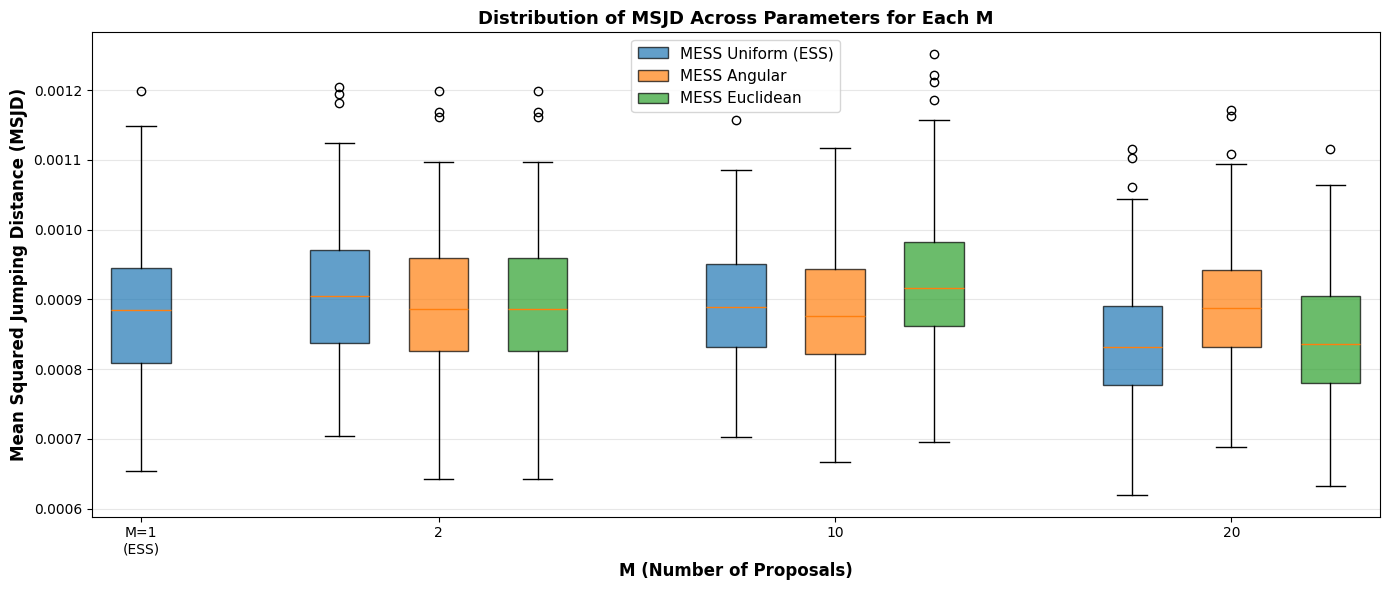

In [23]:
# Prepare boxplot data for MSJD comparison
# Include all M values, but M=1 will only have uniform
uniform_msjd_box = []
angular_msjd_box = []
euclidean_msjd_box = []
M_msjd_box_compare = []  # Track which M values we have data for

for M in M_compare:
    # Uniform (available for all M)
    chain_uniform = results['chains'][M][burn_in:, :]
    msjd_uniform = compute_mean_squared_jumping_distance(chain_uniform)
    uniform_msjd_box.append(msjd_uniform)
    
    # Angular (only for M > 1)
    if M > 1:
        chain_angular = results_angular['chains'][M][burn_in+1:, :]
        msjd_angular = compute_mean_squared_jumping_distance(chain_angular)
        angular_msjd_box.append(msjd_angular)
        
        # Euclidean (only for M > 1)
        chain_euclidean = results_euclidean['chains'][M][burn_in+1:, :]
        msjd_euclidean = compute_mean_squared_jumping_distance(chain_euclidean)
        euclidean_msjd_box.append(msjd_euclidean)
    
    M_msjd_box_compare.append(M)

# Create figure with boxplots
fig, ax = plt.subplots(figsize=(14, 6))

# Positions for the boxplots
# For M=1: only uniform at position 0
# For M>1: uniform, angular, euclidean at positions 1, 2, 3 (and repeat pattern)
positions_uniform_msjd = []
positions_angular_msjd = []
positions_euclidean_msjd = []

pos_counter = 0
for i, M in enumerate(M_msjd_box_compare):
    positions_uniform_msjd.append(pos_counter)
    pos_counter += 1
    
    if M > 1:
        positions_angular_msjd.append(pos_counter)
        pos_counter += 1
        positions_euclidean_msjd.append(pos_counter)
        pos_counter += 1
    
    pos_counter += 1  # Add gap between M values

# Create boxplots
bp1 = ax.boxplot(uniform_msjd_box, positions=positions_uniform_msjd, widths=0.6,
                  patch_artist=True, label='MESS Uniform (ESS)')
bp2 = ax.boxplot(angular_msjd_box, positions=positions_angular_msjd, widths=0.6,
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_msjd_box, positions=positions_euclidean_msjd, widths=0.6,
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# Set x-axis labels
x_ticks = []
x_labels = []
for i, M in enumerate(M_msjd_box_compare):
    if M == 1:
        x_ticks.append(positions_uniform_msjd[i])
        x_labels.append(f"M={int(M)}\n(ESS)")
    else:
        # Get average position for the three methods
        j = len([m for m in M_msjd_box_compare[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform_msjd[i] + positions_angular_msjd[j] + positions_euclidean_msjd[j]) / 3
        x_ticks.append(avg_pos)
        x_labels.append(str(int(M)))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Jumping Distance (MSJD)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of MSJD Across Parameters for Each M', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Combined Boxplot Comparison: ESS vs MSJD

Create a single figure with ESS boxplots on the left and MSJD boxplots on the right for direct comparison.


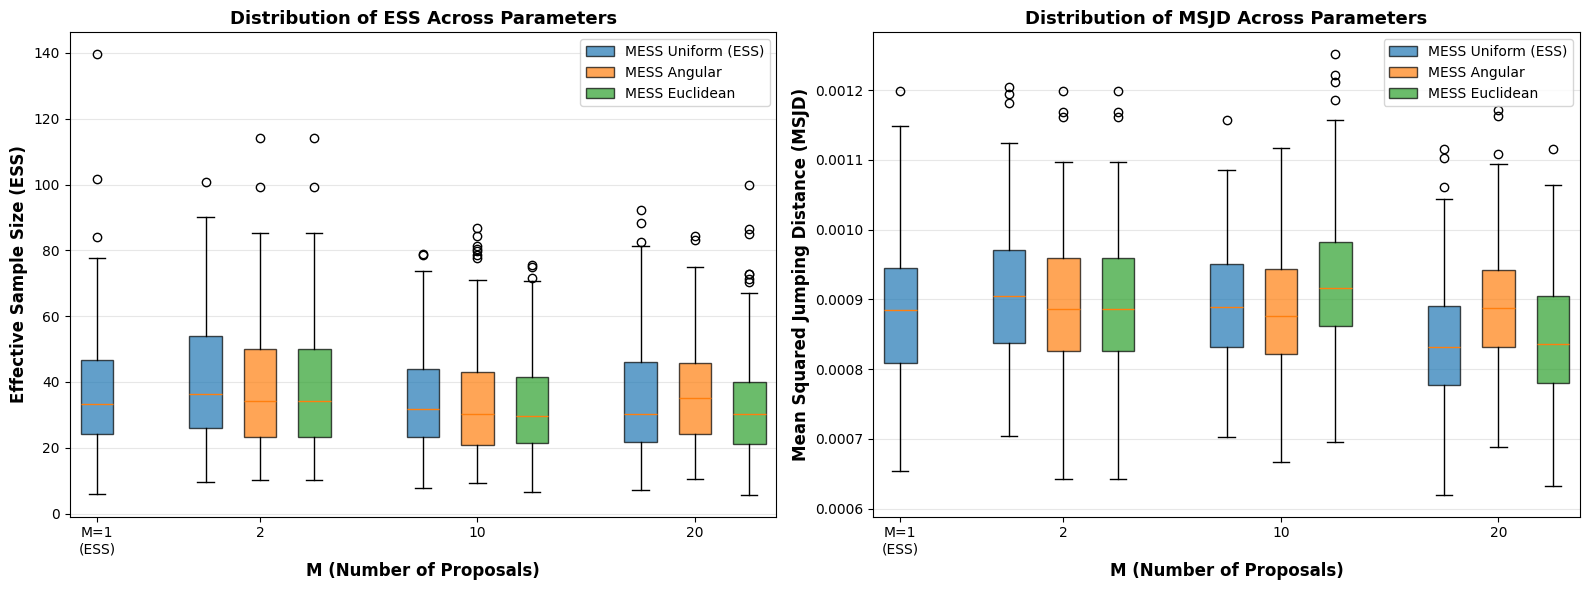

In [24]:
# Create a combined figure with ESS and MSJD boxplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: ESS Boxplots =====
ax = axes[0]

# Create boxplots for ESS
bp1 = ax.boxplot(uniform_ess_box, positions=positions_uniform, widths=0.6,
                  patch_artist=True, label='MESS Uniform (ESS)')
bp2 = ax.boxplot(angular_ess_box, positions=positions_angular, widths=0.6,
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_ess_box, positions=positions_euclidean, widths=0.6,
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# Set x-axis labels for ESS
x_ticks_ess = []
x_labels_ess = []
for i, M in enumerate(M_box_compare):
    if M == 1:
        x_ticks_ess.append(positions_uniform[i])
        x_labels_ess.append(f"M={int(M)}\n(ESS)")
    else:
        j = len([m for m in M_box_compare[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform[i] + positions_angular[j] + positions_euclidean[j]) / 3
        x_ticks_ess.append(avg_pos)
        x_labels_ess.append(str(int(M)))

ax.set_xticks(x_ticks_ess)
ax.set_xticklabels(x_labels_ess)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effective Sample Size (ESS)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of ESS Across Parameters', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='y')

# ===== RIGHT PLOT: MSJD Boxplots =====
ax = axes[1]

# Create boxplots for MSJD
bp1 = ax.boxplot(uniform_msjd_box, positions=positions_uniform_msjd, widths=0.6,
                  patch_artist=True, label='MESS Uniform (ESS)')
bp2 = ax.boxplot(angular_msjd_box, positions=positions_angular_msjd, widths=0.6,
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_msjd_box, positions=positions_euclidean_msjd, widths=0.6,
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# Set x-axis labels for MSJD
x_ticks_msjd = []
x_labels_msjd = []
for i, M in enumerate(M_msjd_box_compare):
    if M == 1:
        x_ticks_msjd.append(positions_uniform_msjd[i])
        x_labels_msjd.append(f"M={int(M)}\n(ESS)")
    else:
        j = len([m for m in M_msjd_box_compare[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform_msjd[i] + positions_angular_msjd[j] + positions_euclidean_msjd[j]) / 3
        x_ticks_msjd.append(avg_pos)
        x_labels_msjd.append(str(int(M)))

ax.set_xticks(x_ticks_msjd)
ax.set_xticklabels(x_labels_msjd)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Jumping Distance (MSJD)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of MSJD Across Parameters', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
